In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import os, pathlib, glob, random
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.metrics import confusion_matrix

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
batch_size = 32
output_nodes = 2
learning_rate = 0.01

In [5]:
train_data_path = r"/home/hemantpatil/ritik/ICPR_Phase_2/LFRCC_feat_20_static_diff_LPOrder/2/train"
valid_data_path = r"/home/hemantpatil/ritik/ICPR_Phase_2/LFRCC_feat_20_static_diff_LPOrder/2/valid"
test_data_path = r"/home/hemantpatil/ritik/ICPR_Phase_2/LFRCC_feat_20_static_diff_LPOrder/2/test"

In [6]:
import scipy

In [7]:
class PtDataset(Dataset):
    def __init__(self, directory):
        self.directory = directory
        self.classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.files = []
        for c in self.classes:
            c_dir = os.path.join(directory, c)
            c_files = [(os.path.join(c_dir, f), self.class_to_idx[c]) for f in os.listdir(c_dir)]
            self.files.extend(c_files)
        random.shuffle(self.files)
        
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        filepath, label = self.files[idx]
        try:
            mat_vals = scipy.io.loadmat(filepath)
            data = mat_vals['final']
            #data = data.T
            max_len=600
            if (max_len > data.shape[0]):
                pad_width = max_len - data.shape[0]
                data = np.pad(data, pad_width=((0, pad_width),(0,0)), mode='constant')
            else:
                data = data[:max_len, :]
        except Exception as e:
            print(f"Error loading file {filepath}: {str(e)}")
            return None
        return data, label

In [8]:
train_dataset = PtDataset(train_data_path)
valid_dataset = PtDataset(valid_data_path)
test_dataset = PtDataset(test_data_path)

In [9]:
class PtDataLoader(DataLoader):
    def __init__(self, directory, batch_size, shuffle=True):
        dataset = PtDataset(directory)
        super().__init__(dataset, batch_size=batch_size, shuffle=shuffle)

In [10]:
train_dataloader = PtDataLoader(directory=train_data_path, batch_size=batch_size)
valid_dataloader = PtDataLoader(directory=valid_data_path, batch_size=batch_size)
test_dataloader = PtDataLoader(directory=test_data_path, batch_size=batch_size)

In [11]:
train_count = len(train_dataset)
valid_count = len(valid_dataset) 
test_count = len(test_dataset)

print(train_count)
print(valid_count)
print(test_count)

53866
10797
4634


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

Modules

In [13]:
class TDNN(nn.Module):
    
    def __init__(
                    self, 
                    input_dim, 
                    output_dim,
                    context_size=5,
                    stride=1,
                    dilation=1,
                    batch_norm=False,
                    dropout_p=0.2
                ):
        super(TDNN, self).__init__()
        self.context_size = context_size
        self.stride = stride
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.dilation = dilation
        self.dropout_p = dropout_p
        self.batch_norm = batch_norm
      
        self.kernel = nn.Linear(input_dim*context_size, output_dim)
        self.nonlinearity = nn.ReLU()
        if self.batch_norm:
            self.bn = nn.BatchNorm1d(output_dim)
        if self.dropout_p:
            self.drop = nn.Dropout(p=self.dropout_p)
        
    def forward(self, x):
        '''
        input: size (batch, seq_len, input_features)
        outpu: size (batch, new_seq_len, output_features)
        '''
        
        _, _, d = x.shape
        assert (d == self.input_dim), 'Input dimension was wrong. Expected ({}), got ({})'.format(self.input_dim, d)
        x = x.unsqueeze(1)

        # Unfold input into smaller temporal contexts
        x = F.unfold(
                        x, 
                        (self.context_size, self.input_dim), 
                        stride=(1,self.input_dim), 
                        dilation=(self.dilation,1)
                    )

        # N, output_dim*context_size, new_t = x.shape
        x = x.transpose(1,2)
        x = self.kernel(x.float())
        x = self.nonlinearity(x)
        
        if self.dropout_p:
            x = self.drop(x)

        if self.batch_norm:
            x = x.transpose(1,2)
            x = self.bn(x)
            x = x.transpose(1,2)

        return x

In [14]:
import torch
from torch import nn
from torch.nn import Parameter
import torch.nn.functional as F

class Classic_Attention(nn.Module):
    def __init__(self,input_dim, embed_dim, attn_dropout=0.0):
        super().__init__()
        self.embed_dim = embed_dim
        self.attn_dropout = attn_dropout
        self.lin_proj = nn.Linear(input_dim,embed_dim)
        self.v = torch.nn.Parameter(torch.randn(embed_dim))
    
    def forward(self,inputs):
        lin_out = self.lin_proj(inputs)
        v_view = self.v.unsqueeze(0).expand(lin_out.size(0), len(self.v)).unsqueeze(2)
        attention_weights = torch.tanh(lin_out.bmm(v_view).squeeze())
        attention_weights_normalized = F.softmax(attention_weights,1)
        return attention_weights_normalized

Model

In [15]:
class Convnet(nn.Module):
    def __init__(self, input_dim = 36, num_classes=2):
        super(Convnet, self).__init__()
        ## Frame level feature processing
        self.tdnn1 = TDNN(input_dim=20, output_dim=512, context_size=5, dilation=1,dropout_p=0.2)
        self.tdnn2 = TDNN(input_dim=512, output_dim=512, context_size=5, dilation=2,dropout_p=0.2)
        self.tdnn3 = TDNN(input_dim=512, output_dim=512, context_size=7, dilation=3,dropout_p=0.2)
        self.tdnn4 = TDNN(input_dim=512, output_dim=512, context_size=1, dilation=1,dropout_p=0.2)
        self.tdnn5 = TDNN(input_dim=512, output_dim=512, context_size=1, dilation=1,dropout_p=0.2)
        ### Statistics attentive pooling
        self.attention = Classic_Attention(512,512)
        #### Frame levelPooling
        self.segment6 = nn.Linear(1024, 512)
        self.segment7 = nn.Linear(512,512 )
        self.output = nn.Linear(512, num_classes)
        self.softmax = nn.Softmax(dim=1)
    
    def weighted_sd(self,inputs,attention_weights, mean):
        el_mat_prod = torch.mul(inputs,attention_weights.unsqueeze(2).expand(-1,-1,inputs.shape[-1]))
        hadmard_prod = torch.mul(inputs,el_mat_prod)
        variance = torch.sum(hadmard_prod,1) - torch.mul(mean,mean)
        return variance
    
    
    def stat_attn_pool(self,inputs,attention_weights):
        el_mat_prod = torch.mul(inputs,attention_weights.unsqueeze(2).expand(-1,-1,inputs.shape[-1]))
        mean = torch.mean(el_mat_prod,1)
        variance = self.weighted_sd(inputs,attention_weights,mean)
        stat_pooling = torch.cat((mean,variance),1)
        return stat_pooling
    
    
    def forward(self, inputs):
        tdnn1_out = self.tdnn1(inputs)
        tdnn2_out = self.tdnn2(tdnn1_out)
        tdnn3_out = self.tdnn3(tdnn2_out)
        tdnn4_out = self.tdnn4(tdnn3_out)
        tdnn5_out = self.tdnn5(tdnn4_out)
        ### Stat Pool
        attn_weights = self.attention(tdnn5_out)
        stat_pool_out = self.stat_attn_pool(tdnn5_out,attn_weights)
        segment6_out = self.segment6(stat_pool_out)
        x_vec = self.segment7(segment6_out)
        predictions = self.output(x_vec)
        return predictions,x_vec

In [16]:
model = Convnet().to(device)

In [17]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

In [18]:
import scipy
from scipy import io
num_epochs = 15

In [19]:
#Model training and testing 
n_total_steps = len(train_dataloader) # n_total_steps * batch size will give total number of training files (consider that last batch may not be fully filled)
train_accuracy_list = []
train_loss_list = []
valid_accuracy_list = []
max_acc = 0
pred_labels =[]
act_labels = []
pred =[]
lab =[]

In [20]:
# for loop for iterates over each epoch
for epoch in range(num_epochs):
    
    #Evaluation and training on training dataset
    model.train()
    train_accuracy=0.0
    train_loss=0.0 #accummulated for each epoch
    #loop through each batch from train dataloader and move to cuda/gpu
    for batch_idx, (images,labels) in enumerate(tqdm(train_dataloader)):
        if torch.cuda.is_available():
            images=images.to(device)
            labels=labels.to(device)
        ##images = images.unsqueeze(1)
        optimizer.zero_grad()# to prevent accumulation pass the images through model to get o/p
        outputs=model(images)
        outputs=outputs[0]
        loss=loss_function(outputs,labels)
        loss.backward() # performs backpropogation
        optimizer.step() # updates models 
        
        
        train_loss+= loss.cpu().data*images.size(0) # loss for entire epoch
        _,prediction=torch.max(outputs.data,1)
        
        train_accuracy+=int(torch.sum(prediction==labels.data)) # count of correct predictions and accuraccy
        
    train_accuracy=train_accuracy/train_count  # avg training accuracy and loss for the epoch
    train_loss=train_loss/train_count   

    train_accuracy_list.append(train_accuracy)#Append the results
    train_loss_list.append(train_loss)

    
    # Evaluation on validation dataset
    model.eval()
    valid_accuracy=0.0
    # loop 
    for i, (images,labels) in enumerate(tqdm(valid_dataloader)):
        if torch.cuda.is_available():
            images=Variable(images.to(device)) # move to device
            labels=Variable(labels.to(device))
        ##images = images.unsqueeze(1) 
        # Pass the validation images through the model to get predictions.
        #Extract the first element of the output tuple.  
        outputs=model(images)
        outputs=outputs[0]
        _,prediction=torch.max(outputs.data,1)
        valid_accuracy+=int(torch.sum(prediction==labels.data))# correct predictions and acc
    
    valid_accuracy=valid_accuracy/valid_count
    valid_accuracy_list.append(valid_accuracy) # result  tracking
    
    if(max_acc < valid_accuracy):
        pred_labels=[]
        act_labels=[]
        pred_labels = pred
        act_labels = lab
        max_acc = valid_accuracy
        torch.save(model, 'model.pth')
    
    print('Epoch : '+str(epoch+1)+'/'+str(num_epochs)+'   Train Loss : '+str(train_loss)+'   Train Accuracy : '+str(train_accuracy)+'   Valid Accuracy : '+str(valid_accuracy))

print('Finished Training')
print('max accuracy', max_acc)

100%|██████████| 338/338 [00:55<00:00,  6.05it/s]
/home/hemantpatil/anaconda3/envs/conda_hifi_env/lib/python3.8/site-packages/torch/serialization.py:359: UserWarning: Couldn't retrieve source code for container of type Convnet. It won't be checked for correctness upon loading.
  warnings.warn("Couldn't retrieve source code for container of "
/home/hemantpatil/anaconda3/envs/conda_hifi_env/lib/python3.8/site-packages/torch/serialization.py:359: UserWarning: Couldn't retrieve source code for container of type TDNN. It won't be checked for correctness upon loading.
  warnings.warn("Couldn't retrieve source code for container of "
/home/hemantpatil/anaconda3/envs/conda_hifi_env/lib/python3.8/site-packages/torch/serialization.py:359: UserWarning: Couldn't retrieve source code for container of type Classic_Attention. It won't be checked for correctness upon loading.
  warnings.warn("Couldn't retrieve source code for container of "


Epoch : 1/15   Train Loss : tensor(0.3048)   Train Accuracy : 0.8621022537407641   Valid Accuracy : 0.9629526720385292


100%|██████████| 338/338 [00:55<00:00,  6.05it/s]


Epoch : 2/15   Train Loss : tensor(0.1245)   Train Accuracy : 0.9554078639587124   Valid Accuracy : 0.9774937482634065


100%|██████████| 338/338 [00:55<00:00,  6.05it/s]


...

Epoch : 13/15   Train Loss : tensor(0.0132)   Train Accuracy : 0.9961385660713623   Valid Accuracy : 0.9974993053626007


100%|██████████| 338/338 [00:55<00:00,  6.06it/s]


Epoch : 14/15   Train Loss : tensor(0.0086)   Train Accuracy : 0.9977351204841645   Valid Accuracy : 0.9985181068815412


100%|██████████| 338/338 [00:55<00:00,  6.05it/s]

Epoch : 15/15   Train Loss : tensor(0.0109)   Train Accuracy : 0.9968997141053726   Valid Accuracy : 0.9929610076873205
Finished Training
max accuracy 0.9985181068815412


In [21]:
# Load the best model
best_model = torch.load('model.pth')

# Put the best_model in evaluation mode
best_model.eval()

# Initialize variables to store results
test_accuracy = 0.0
pred_labels = []
act_labels = [] # empty list stores actual lables

# Pass validation data through the best model
for i, (images, labels) in enumerate(tqdm(test_dataloader)):
    if torch.cuda.is_available():
        images = images.to(device)
        labels = labels.to(device)
   
    #images = images.unsqueeze(1)
    images = images.float()
    outputs = best_model(images)
    outputs=outputs[0] #extract the first element
    _, prediction = torch.max(outputs.data, 1) #  to get the index of the maximum value in the output tensor along the specified dimension
   
    test_accuracy += int(torch.sum(prediction == labels.data))
   
    pred_labels.extend(prediction.tolist())
    act_labels.extend(labels.tolist())

# Calculate testing accuracy
test_accuracy = test_accuracy / test_count

# Print the testing accuracy
print("testing Accuracy:", test_accuracy)

100%|██████████| 145/145 [00:23<00:00,  6.09it/s]

testing Accuracy: 0.9503668536901165


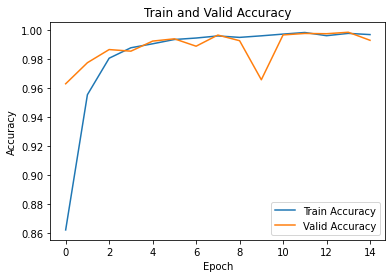

In [22]:
plt.plot(train_accuracy_list, label='Train Accuracy')
plt.plot(valid_accuracy_list, label='Valid Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train and Valid Accuracy')
plt.legend()

plt.show()

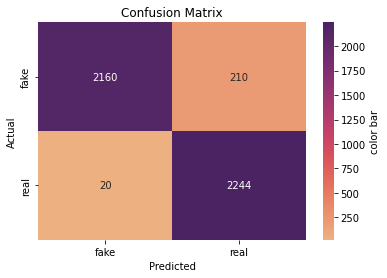

F1 Score :  0.9504037544543213


In [23]:
# Calculate the confusion matrix
import seaborn as sns
conf_mat = confusion_matrix(act_labels, pred_labels)
# Plot confusion matrix heat map
sns.heatmap(conf_mat, cmap="flare",annot=True, fmt = "g",
            cbar_kws={"label":"color bar"},
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
# plt.savefig("ConfusionMatrix_BiLSTM.png")
plt.show()
from sklearn.metrics import f1_score
f1_score = f1_score(pred_labels, act_labels, average='weighted')
print('F1 Score : ', f1_score)

In [24]:
import numpy as np
import sklearn.metrics

"""
Python compute equal error rate (eer)
ONLY tested on binary classification

:param label: ground-truth label, should be a 1-d list or np.array, each element represents the ground-truth label of one sample
:param pred: model prediction, should be a 1-d list or np.array, each element represents the model prediction of one sample
:param positive_label: the class that is viewed as positive class when computing EER
:return: equal error rate (EER)
"""
def compute_eer(act_labels, pred_labels, positive_label=1):
    # all fpr, tpr, fnr, fnr, threshold are lists (in the format of np.array)
    fpr, tpr, threshold = sklearn.metrics.roc_curve(act_labels, pred_labels)
    fnr = 1 - tpr

    # the threshold of fnr == fpr
    eer_threshold = threshold[np.nanargmin(np.absolute((fnr - fpr)))]

    # theoretically eer from fpr and eer from fnr should be identical but they can be slightly differ in reality
    eer_1 = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
    eer_2 = fnr[np.nanargmin(np.absolute((fnr - fpr)))]

    # return the mean of eer from fpr and from fnr
    eer = (eer_1 + eer_2) / 2
    return eer

# Call the function to compute EER
eer_result = compute_eer(act_labels, pred_labels)

# Print the result
print("Equal Error Rate:", eer_result)

Equal Error Rate: 0.048720758599096456


In [25]:
from sklearn.metrics import f1_score, jaccard_score, matthews_corrcoef, hamming_loss,accuracy_score

f1 = f1_score(act_labels, pred_labels, average='weighted')
jaccard = jaccard_score(act_labels, pred_labels, average='weighted')
mcc = matthews_corrcoef(act_labels, pred_labels)
hloss = hamming_loss(act_labels, pred_labels)

print(f1)
print(jaccard)
print(mcc)
print(hloss)

0.9503299529259119
0.9053620470013881
0.9039037967411658
0.04963314630988347
